## Survival Analysis: Time Until a >=5% Daily Price Increase

In this section, I reframe stock prediction as a survival analysis problem.
Instead of predicting an exact next-day value, I model the time until the next
>=5% daily increase in stock price.

This provides timing-focused insight for risk management and holding-period decisions.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [2]:
data_path = Path("../01_data/raw/df_eda.csv")
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (40351, 17)


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Target_Return_1d,Weekday,Month
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412385,493729600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,0.001729,Monday,January
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423469,601904800,AAPL,0.001729,NaN,NaN,NaN,NaN,0.219098,-0.015906,Tuesday,January
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321294,552160000,AAPL,-0.015906,NaN,NaN,NaN,NaN,-0.082646,-0.001849,Wednesday,January
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL,-0.001849,-0.016028,NaN,NaN,NaN,-0.135882,0.006648,Thursday,January
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351558,447610800,AAPL,0.006648,-0.011195,NaN,NaN,NaN,-0.061871,-0.008821,Friday,January


### Prepare the dataset

The dataset already contains lagged return, volatility, and volume-based features,
so I use them directly as predictors.

I also create log-transformed volume to reduce scale effects.
To avoid leakage, the data is split by date before model fitting.


In [3]:
df_surv = df.copy()

df_surv["Date"] = pd.to_datetime(df_surv["Date"])
df_surv = df_surv.sort_values(["Ticker", "Date"]).reset_index(drop=True)

df_surv["Target_Next_Close"] = df_surv.groupby("Ticker")["Close"].shift(-1)
df_surv["Price_Change_Pct_1d"] = (df_surv["Target_Next_Close"] / df_surv["Close"]) - 1

df_surv["Log_Volume"] = np.log1p(df_surv["Volume"])

numeric_features = [
    "Return_1d",
    "Return_3d",
    "Return_5d",
    "Volatility_5d",
    "Volatility_20d",
    "Volume_Change_1d",
    "Log_Volume"
]

categorical_features = ["Ticker", "Weekday", "Month"]

base_cols = ["Date", "Close", "Target_Next_Close", "Price_Change_Pct_1d"] + numeric_features + categorical_features
df_surv = df_surv[base_cols].copy()

df_surv = df_surv.dropna(subset=numeric_features + ["Price_Change_Pct_1d", "Target_Next_Close", "Close"]).reset_index(drop=True)

df_surv.head()


,Date,Close,Target_Next_Close,Price_Change_Pct_1d,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Log_Volume,Ticker,Weekday,Month
0,2010-02-02,6.995000,7.115357,0.017206,0.005803,-0.017211,-0.048946,0.026783,0.022815,-0.068723,20.364220,AAPL,Tuesday,February
1,2010-02-03,7.115357,6.858929,-0.036039,0.017206,0.037332,-0.041610,0.028353,0.023284,-0.118873,20.237666,AAPL,Wednesday,February
2,2010-02-04,6.858929,6.980714,0.017756,-0.036039,-0.013762,-0.036329,0.026866,0.024267,0.231298,20.445735,AAPL,Thursday,February
3,2010-02-05,6.980714,6.932857,-0.006856,0.017755,-0.002043,0.017703,0.022736,0.024767,0.122292,20.561108,AAPL,Friday,February
4,2010-02-08,6.932857,7.006786,0.010664,-0.006856,-0.025649,-0.003132,0.022304,0.024661,-0.437531,19.985688,AAPL,Monday,February


### Split data chronologically

I use a time-based split so that the model is trained on earlier observations and evaluated on later ones.  
This better reflects a realistic forecasting setup.

In [4]:
unique_dates = np.sort(df_surv["Date"].unique())
split_idx = int(len(unique_dates) * 0.8)
split_date = unique_dates[split_idx]

train_raw = df_surv[df_surv["Date"] < split_date].copy()
test_raw = df_surv[df_surv["Date"] >= split_date].copy()

print("Split date:", pd.to_datetime(split_date).date())
print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)

Split date: 2023-01-12
Train shape: (31991, 14)
Test shape: (8150, 14)


### Create survival target

The event is defined as a next-day price increase of at least 5%.
For each row, I calculate:
- Event_Next_5pct: whether the next day reaches the 5% threshold
- Duration: number of trading days until the next such event
- Observed: whether the event is observed (1) or right-censored (0)


In [5]:
def build_survival_dataset(data, threshold=0.05):
    """
    Create survival targets for each ticker and keep the Ticker column.

    Computes whether a >=5% next-day price-increase event occurs, how many trading
    days remain until that event, and whether the event is observed or right-censored.
    """
    def per_ticker(group):
        ticker = group.name
        g = group.sort_values("Date").copy()
        g["Ticker"] = ticker

        event_now = (g["Price_Change_Pct_1d"] >= threshold).astype(int).to_numpy()
        n = len(g)

        durations = np.zeros(n, dtype=int)
        observed = np.zeros(n, dtype=int)

        next_event_idx = None

        for i in range(n - 1, -1, -1):
            if event_now[i] == 1:
                next_event_idx = i
                durations[i] = 1
                observed[i] = 1
            else:
                if next_event_idx is None:
                    durations[i] = n - i
                    observed[i] = 0
                else:
                    durations[i] = next_event_idx - i + 1
                    observed[i] = 1

        g["Event_Next_5pct"] = event_now
        g["Duration"] = durations
        g["Observed"] = observed

        return g

    return (
        data.groupby("Ticker", group_keys=False)
        .apply(per_ticker, include_groups=False)
        .reset_index(drop=True)
    )

full_surv = build_survival_dataset(df_surv)
train_surv = build_survival_dataset(train_raw)
test_surv = build_survival_dataset(test_raw)

full_surv.head()


,Date,Close,Target_Next_Close,Price_Change_Pct_1d,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Log_Volume,Weekday,Month,Ticker,Event_Next_5pct,Duration,Observed
0,2010-02-02,6.995000,7.115357,0.017206,0.005803,-0.017211,-0.048946,0.026783,0.022815,-0.068723,20.364220,Tuesday,February,AAPL,0,54,1
1,2010-02-03,7.115357,6.858929,-0.036039,0.017206,0.037332,-0.041610,0.028353,0.023284,-0.118873,20.237666,Wednesday,February,AAPL,0,53,1
2,2010-02-04,6.858929,6.980714,0.017756,-0.036039,-0.013762,-0.036329,0.026866,0.024267,0.231298,20.445735,Thursday,February,AAPL,0,52,1
3,2010-02-05,6.980714,6.932857,-0.006856,0.017755,-0.002043,0.017703,0.022736,0.024767,0.122292,20.561108,Friday,February,AAPL,0,51,1
4,2010-02-08,6.932857,7.006786,0.010664,-0.006856,-0.025649,-0.003132,0.022304,0.024661,-0.437531,19.985688,Monday,February,AAPL,0,50,1


,Date,Close,Target_Next_Close,Price_Change_Pct_1d,Duration,Observed
0,2010-02-26,5.920000,6.227000,0.051858,1,1
1,2010-03-24,6.402000,6.736500,0.052249,1,1
2,2010-04-20,8.735357,9.257857,0.059814,1,1
3,2010-05-07,8.423571,9.071071,0.076868,1,1
4,2010-05-07,33.430000,35.290001,0.055639,1,1
...,...,...,...,...,...,...
338,2026-03-30,536.380005,572.130005,0.066651,1,1
339,2026-03-30,273.500000,287.559998,0.051408,1,1
340,2026-04-07,575.049988,612.419983,0.064986,1,1
341,2026-04-07,318.769989,336.160004,0.054553,1,1


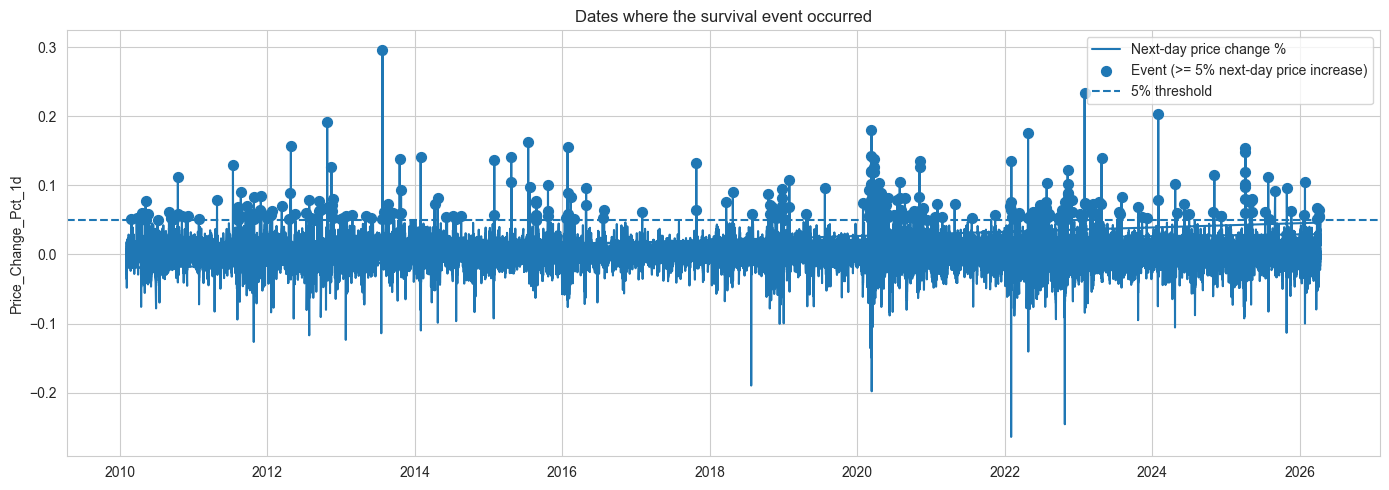

In [6]:
event_df = full_surv.copy()

event_df["Date"] = pd.to_datetime(event_df["Date"])

events_only = event_df[event_df["Event_Next_5pct"] == 1].copy()

display(
    events_only[["Date", "Close", "Target_Next_Close", "Price_Change_Pct_1d", "Duration", "Observed"]]
    .sort_values("Date")
    .reset_index(drop=True)
)

plt.figure(figsize=(14, 5))
plt.plot(event_df["Date"], event_df["Price_Change_Pct_1d"], label="Next-day price change %")
plt.scatter(
    events_only["Date"],
    events_only["Price_Change_Pct_1d"],
    s=50,
    label="Event (>= 5% next-day price increase)"
)

plt.axhline(0.05, linestyle="--", label="5% threshold")
plt.title("Dates where the survival event occurred")
plt.xlabel("")
plt.ylabel("Price_Change_Pct_1d")
plt.legend()
plt.tight_layout()
plt.show()


The plot shows that >=5% next-day price-increase events are relatively rare compared
with normal daily movements.


### Check event frequency and censoring

Before fitting the model, I inspect how often the event happens and how much censoring is present.  
This is important because a 5% next-day increase is relatively rare for large-cap stocks.

In [7]:
event_summary = (
    full_surv.groupby("Ticker").agg(
        Rows=("Ticker", "size"),
        Event_Rate=("Event_Next_5pct", "mean"),
        Observed_Rate=("Observed", "mean"),
        Median_Duration=("Duration", "median")
    )
    .reset_index()
)

event_summary

,Ticker,Rows,Event_Rate,Observed_Rate,Median_Duration
0,AAPL,4074,0.009573,0.957536,82.0
1,AMZN,4074,0.015464,0.999018,50.0
2,GOOGL,4074,0.009082,0.997545,85.0
3,HD,4074,0.005400,0.998773,177.0
4,JNJ,4074,0.002209,0.953854,482.5
5,JPM,4074,0.009327,0.937653,165.0
6,META,3475,0.021871,0.998561,49.0
7,MSFT,4074,0.007118,0.941335,113.5
8,PG,4074,0.001718,0.626902,839.5
9,XOM,4074,0.005646,0.813451,292.0


The event is rare for all stocks, with event rates below **3%**.  
**META** and **AMZN** still show the highest event frequency and shorter median waiting times,\
while lower-volatility stocks such as **PG** and **JNJ** have much longer waiting times.  
Observed rates are high for several stocks, but not equally high across the full sample.

### Kaplan-Meier curves

As a descriptive baseline, I plot Kaplan-Meier survival curves for each stock.  
These curves show the probability that a **5% next-day increase has not yet occurred**\
after a given number of trading days.  

We need this step to get a simple, model-free view of **how quickly the event tends to happen**\
and to compare survival patterns across stocks before fitting survival models.

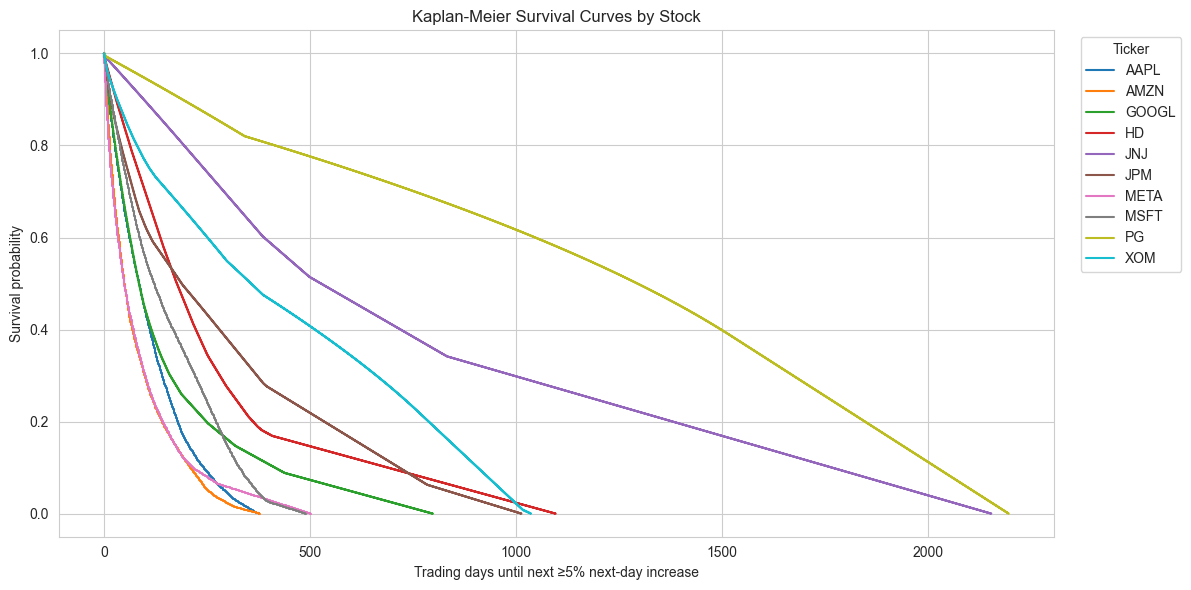

In [8]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(12, 6))

for ticker, temp in full_surv.groupby("Ticker"):
    kmf.fit(
        durations=temp["Duration"],
        event_observed=temp["Observed"],
        label=ticker
    )
    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan-Meier Survival Curves by Stock")
plt.xlabel("Trading days until next ≥5% next-day increase")
plt.ylabel("Survival probability")
plt.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The lines go down as time passes, which means the chance of not seeing a 5% next-day
price increase becomes smaller over time.
Stocks with higher event rates fall faster, while more defensive names fall more slowly,
which suggests longer waiting times until the event.


### Prepare data for the Cox proportional hazards model

I use a pooled Cox proportional hazards model as a baseline survival model.  
It estimates how the features affect the **hazard**, meaning the chance that the\
event happens sooner rather than later.

Ticker, weekday, and month are included as categorical variables, so the model\
remains shared across all stocks while still accounting for differences between them.  

We need this step to build a **single interpretable survival model** that can show\
which factors are linked to faster or slower time until a **5%** next-day gain.

In [9]:
model_features = numeric_features + categorical_features

X_train = pd.get_dummies(
    train_surv[model_features],
    columns=categorical_features,
    drop_first=True
)

X_test = pd.get_dummies(
    test_surv[model_features],
    columns=categorical_features,
    drop_first=True
)

# Align columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# Scale numeric columns
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

cox_train = pd.concat(
    [X_train.reset_index(drop=True),
     train_surv[["Duration", "Observed"]].reset_index(drop=True)],
    axis=1
)

cox_test = pd.concat(
    [X_test.reset_index(drop=True),
     test_surv[["Duration", "Observed"]].reset_index(drop=True)],
    axis=1
)

cox_train.head()

,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Log_Volume,Ticker_AMZN,Ticker_GOOGL,Ticker_HD,Ticker_JNJ,Ticker_JPM,Ticker_META,Ticker_MSFT,Ticker_PG,Ticker_XOM,Weekday_Monday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday,Month_August,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,Duration,Observed
0,0.295419,-0.678250,-1.442982,1.253471,0.929256,-0.316578,2.852382,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,54,1
1,0.963654,1.222232,-1.242020,1.405065,0.983985,-0.441237,2.745574,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,53,1
2,-2.156692,-0.558092,-1.097321,1.261494,1.098916,0.429187,2.921177,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,52,1
3,0.995857,-0.149739,0.382889,0.862522,1.157279,0.158230,3.018548,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,51,1
4,-0.446450,-0.972269,-0.187899,0.820830,1.144983,-1.233329,2.532913,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,50,1


This table shows the final training data used for the Cox proportional hazards model.  
Numeric variables were standardized, while ticker, weekday, and month were converted into dummy variables.  
Because `drop_first=True` was used, one category from each categorical feature is left out and becomes\
the **reference group**. For example, **Friday** is the baseline weekday, so the other weekday columns\
are interpreted relative to Friday.  

The target columns **Duration** and **Observed** were then added, so the dataset is ready for survival modeling.

### Fit the Cox model

Positive coefficients indicate a higher hazard, meaning the 5% increase is expected to happen sooner.  
Negative coefficients indicate a lower hazard, meaning the event is expected to take longer.

In [10]:
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_train, duration_col="Duration", event_col="Observed")

cph.summary[["coef", "exp(coef)", "p"]].sort_values("coef", ascending=False).head(15)

,coef,exp(coef),p
covariate,,,
Ticker_META,0.587354,1.799221,2.838306e-125
Ticker_AMZN,0.440924,1.554142,8.675441e-92
Ticker_MSFT,0.296469,1.345101,2.282019e-41
Volatility_20d,0.260920,1.298124,4.160642e-263
Log_Volume,0.252882,1.287731,1.169833e-182
Month_July,0.145073,1.156124,2.897591e-10
Volatility_5d,0.071236,1.073835,5.108342e-23
Month_October,0.063087,1.065119,5.563007e-03
Month_June,0.056262,1.057875,1.413995e-02


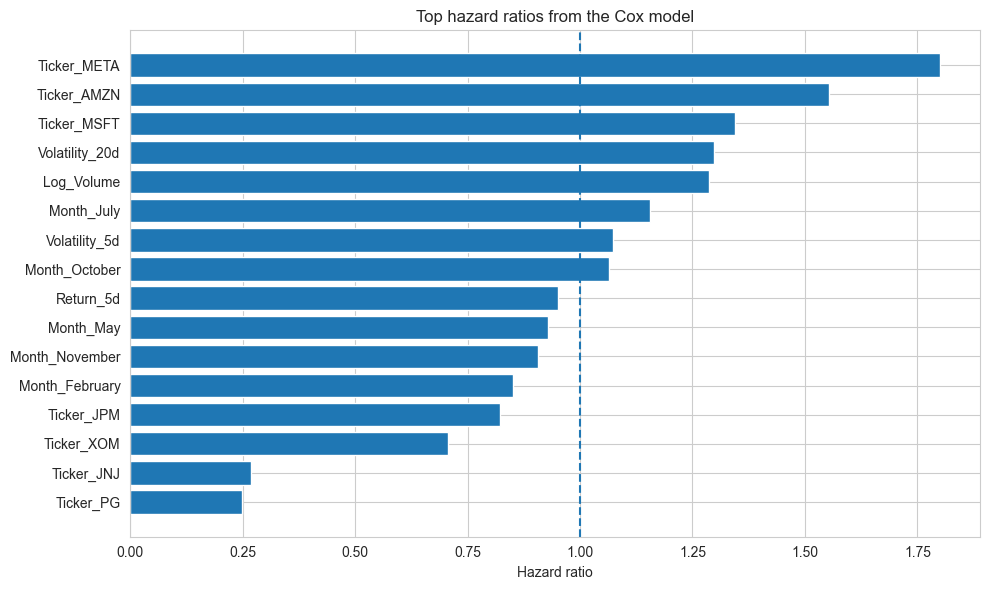

In [11]:
cox_summary = cph.summary.reset_index()[["covariate", "coef", "exp(coef)", "p"]]

top_pos = cox_summary.sort_values("exp(coef)", ascending=False).head(8)
top_neg = cox_summary.sort_values("exp(coef)", ascending=True).head(8)

plot_df = pd.concat([top_neg, top_pos]).drop_duplicates().sort_values("exp(coef)")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["covariate"], plot_df["exp(coef)"])
plt.axvline(1, linestyle="--")
plt.title("Top hazard ratios from the Cox model")
plt.xlabel("Hazard ratio")
plt.ylabel("")
plt.tight_layout()
plt.show()

With a 0.1 penalty, the Cox model remains regularized but still keeps the main
signals visible.
A stronger positive coefficient implies the model expects a >=5% next-day price
increase to happen sooner.


### Evaluate the model

I evaluate the survival model using the **concordance index (C-index)**.  
This tells us how well the model can **rank rows by which one is more likely to reach the event sooner**.

We need this metric because survival analysis focuses on **event timing**, not just whether the event happens.  
A higher C-index means the model is better at identifying which observations are likely to experience the 5% next-day gain earlier.

In [12]:
test_eval = test_surv.reset_index(drop=True).copy()

test_eval["Risk_Score"] = cph.predict_partial_hazard(X_test).values.flatten()

overall_cindex = concordance_index(
    event_times=test_eval["Duration"],
    predicted_scores=-test_eval["Risk_Score"],
    event_observed=test_eval["Observed"]
)

print(f"Overall test C-index: {overall_cindex:.4f}")

Overall test C-index: 0.7062


The overall test **C-index is 0.7062**, which is clearly better than random ranking.
This means the model captures useful signal about which rows are likely to reach the event
sooner, although ticker-level performance is still uneven.


In [13]:
def safe_cindex(group):
    """Return C-index for one stock group, or NaN if it cannot be computed."""
    try:
        return concordance_index(
            event_times=group["Duration"],
            predicted_scores=-group["Risk_Score"],
            event_observed=group["Observed"]
        )
    except Exception:
        return np.nan

stock_results = (
    test_eval.groupby("Ticker")[["Duration", "Risk_Score", "Observed", "Event_Next_5pct"]]
    .apply(lambda g: pd.Series({
        "Rows": len(g),
        "Event_Rate": g["Event_Next_5pct"].mean(),
        "Observed_Rate": g["Observed"].mean(),
        "Median_Actual_Duration": g["Duration"].median(),
        "C_Index": safe_cindex(g)
    }))
    .reset_index()
    .sort_values("C_Index", ascending=False)
)

stock_results

,Ticker,Rows,Event_Rate,Observed_Rate,Median_Actual_Duration,C_Index
9,XOM,815.0,0.001227,0.067485,353.0,0.697225
7,MSFT,815.0,0.003681,0.706748,161.0,0.580509
5,JPM,815.0,0.003681,0.688344,121.0,0.563015
1,AMZN,815.0,0.011043,0.995092,53.0,0.551497
0,AAPL,815.0,0.006135,0.787730,101.0,0.528798
4,JNJ,815.0,0.002454,0.769325,140.0,0.518535
3,HD,815.0,0.003681,0.993865,135.0,0.514475
6,META,815.0,0.015951,0.993865,52.0,0.490350
2,GOOGL,815.0,0.013497,0.987730,48.0,0.448469
8,PG,815.0,0.000000,0.000000,408.0,NaN


The model performs better for some stocks than for others, with several C-index values above 0.5 while\
others remain close to random or cannot be computed cleanly.  
This suggests the pooled Cox model captures some signal, but results are still inconsistent across stocks.

### Visualize survival model performance by stock

To make the results easier to compare, I visualize the C-index for each stock separately.

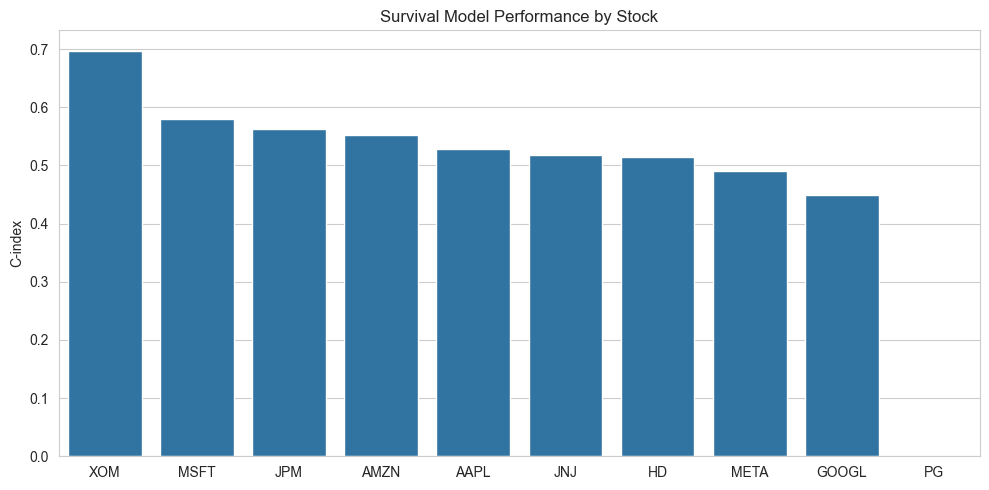

In [14]:
plt.figure(figsize=(10, 5))
sns.barplot(data=stock_results, x="Ticker", y="C_Index")
plt.title("Survival Model Performance by Stock")
plt.xlabel("")
plt.ylabel("C-index")
plt.tight_layout()
plt.show()

### Survival analysis conclusions

Survival analysis helps model when a large positive price move may happen, not just
whether it happens.
The Kaplan-Meier curves show waiting-time patterns by stock, while the Cox model
ranks rows by event timing risk.
